In [1]:
import numpy as np
import networkx as nx

import os

%load_ext autoreload
%autoreload 2

In [2]:
results_dir = "erdos_renyi_n=100_p=0.3_num_runs_2"

In [6]:
G = np.load(f"{results_dir}/erdos_renyi_n=100_p=0.3.npy", allow_pickle=True)[0]

## How to load HierarchicalRunMetadata results from a results dir

In [9]:
from Qommunity.searchers.utils import HierarchicalRunMetadata


num_runs = 2

hierarchical_metadatas = []


for iter in range(num_runs):
    base_filename = f"{results_dir}/_iter_{iter}" # Added this _iter_ prefix to identify
    hm = HierarchicalRunMetadata.load_from_files(base_filename)
    hierarchical_metadatas.append(hm)

Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
DWave sampleset info loaded.
Embeddings info loaded
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
DWave sampleset info loaded.
Embeddings info loaded


Loading iterative searcher other data:

In [20]:
import numpy as np


communities = np.load(f"{results_dir}/_communities.npy", allow_pickle=True)
division_modularities = np.load(f"{results_dir}/_division_modularities.npy", allow_pickle=True)
division_trees = np.load(f"{results_dir}/_division_trees.npy", allow_pickle=True)

In [32]:
from utils import recover_ordering, recover_info_ordering, plot_tree_info

## Recover the binary tree structure of the hierarchical process
division_tree is needed

## Plot the info (chain_strenght and CBF) tree

c:\Users\basia\anaconda3\envs\qomm_env\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: Could not load "C:\Users\basia\anaconda3\envs\qomm_env\Library\bin\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


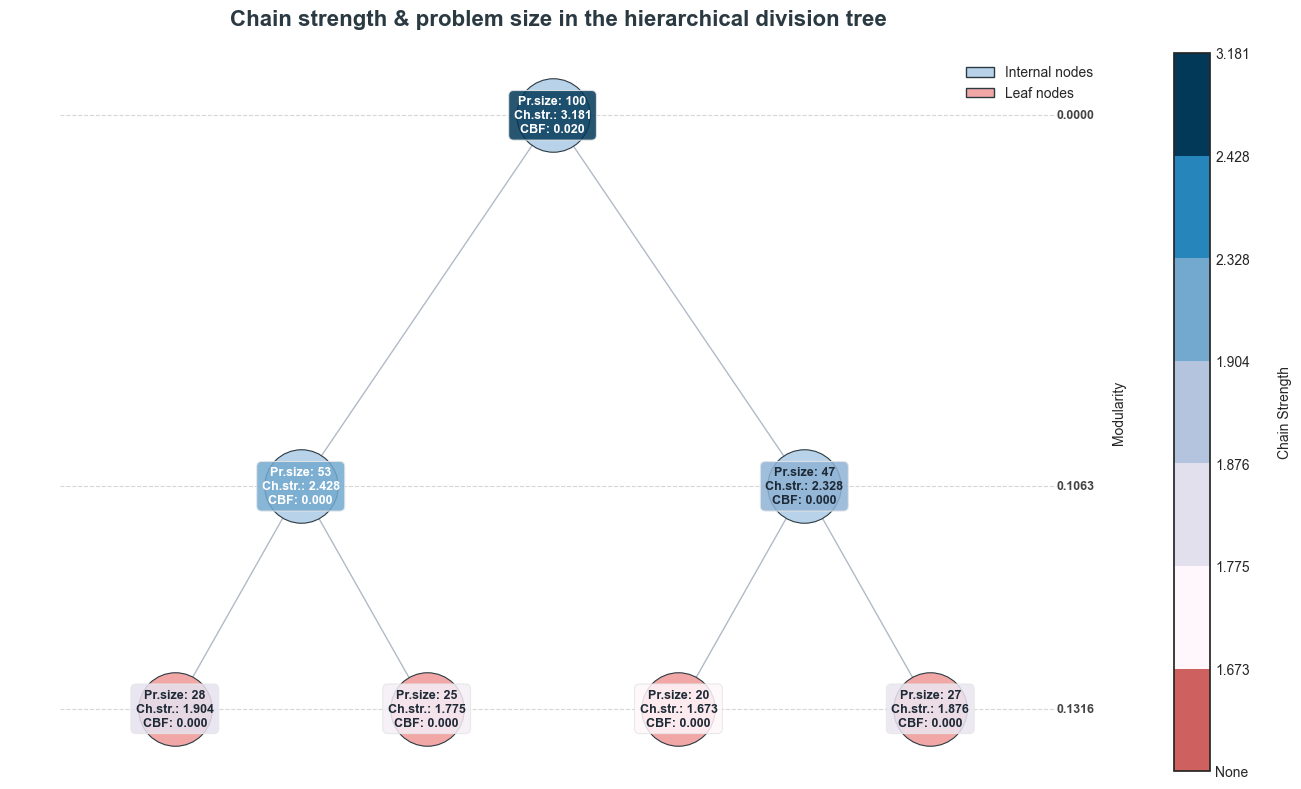

In [37]:
nodes, root = recover_ordering(G=G, division_tree=division_trees[0])
nodes_info, root_info = recover_info_ordering(root=root, nodes=nodes, sampleset_metadata=hierarchical_metadatas[0])

from matplotlib import colormaps


cmap = colormaps.get_cmap("PuBu")
plot_tree_info(root_info, division_modularities[0], cmap=cmap)